# 06 - Model Evaluation

Evaluate the trained CNN (`cnn_best.keras`) on the held-out test set.

This notebook reproduces the exact preprocessing and split from `05_cnn_classifier.ipynb` so the test data matches what the model was trained against.

**Label convention:** `0 = normal`, `1 = abnormal`.

In [1]:
import numpy as np

X = np.load("../data/processed/X.npy")
y = np.load("../data/processed/y.npy")

print(X.shape)
print(y.shape)

(4205, 128, 313)
(4205,)


In [2]:
X = (X - X.min()) / (X.max() - X.min())
X = X[..., np.newaxis]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("normal in test:", (y_test == 0).sum())
print("abnormal in test:", (y_test == 1).sum())

X_train: (3364, 128, 313, 1)
X_test: (841, 128, 313, 1)
y_test: (841,)
normal in test: 750
abnormal in test: 91


In [4]:
from tensorflow import keras

model = keras.models.load_model("../models/cnn_best.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 313, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 313, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 156, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 156, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 156, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 78, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 78, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 39, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 79872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,223,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,951,429 (118.07 MB)

 Trainable params: 10,316,993 (39.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 20,633,988 (78.71 MB)

In [5]:
y_proba = model.predict(X_test, verbose=1).ravel()
y_pred = (y_proba >= 0.5).astype(int)

print("y_proba shape:", y_proba.shape)
print("predicted abnormal:", (y_pred == 1).sum())

 1/27 ━━━━━━━━━━━━━━━━━━━━ 20s 803ms/step

 2/27 ━━━━━━━━━━━━━━━━━━━━ 9s 396ms/step 

 3/27 ━━━━━━━━━━━━━━━━━━━━ 9s 399ms/step

 4/27 ━━━━━━━━━━━━━━━━━━━━ 8s 372ms/step

 5/27 ━━━━━━━━━━━━━━━━━━━━ 8s 373ms/step

...

25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step

27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 377ms/step


y_proba shape: (841,)
predicted abnormal: 71


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

report = classification_report(
    y_test,
    y_pred,
    target_names=["normal", "abnormal"],
    digits=4
)
print(report)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

      normal     0.9649    0.9907    0.9776       750
    abnormal     0.9014    0.7033    0.7901        91

    accuracy                         0.9596       841
   macro avg     0.9332    0.8470    0.8839       841
weighted avg     0.9581    0.9596    0.9573       841

Accuracy:  0.9596
Precision: 0.9014
Recall:    0.7033


F1-score:  0.7901


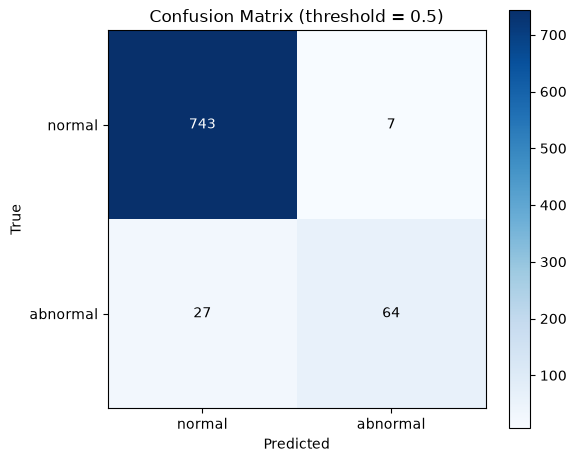

In [7]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["normal", "abnormal"])
ax.set_yticklabels(["normal", "abnormal"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (threshold = 0.5)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im)
plt.tight_layout()
plt.show()

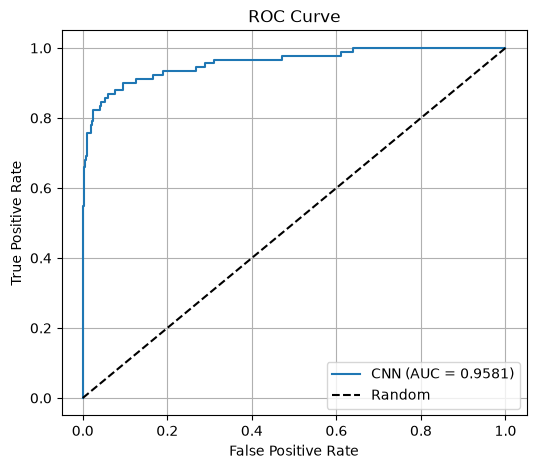

ROC AUC: 0.9581


In [8]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

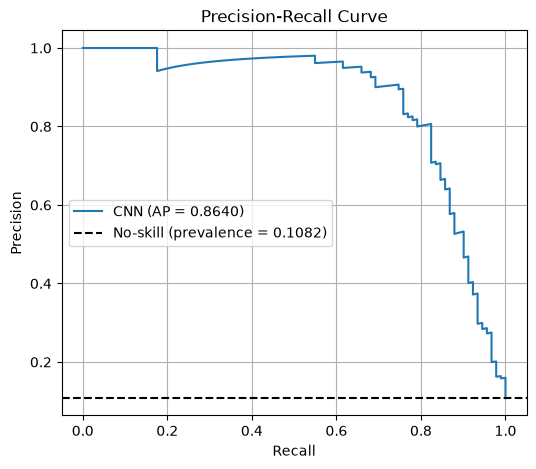

Average Precision: 0.8640


In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
baseline = (y_test == 1).mean()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"CNN (AP = {ap:.4f})")
plt.axhline(baseline, color="k", linestyle="--", label=f"No-skill (prevalence = {baseline:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Precision: {ap:.4f}")

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
n = len(thresholds)
youden = tpr[:n] - fpr[:n]
best_idx = np.argmax(youden)
best_threshold = thresholds[best_idx]

y_pred_opt = (y_proba >= best_threshold).astype(int)

print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print()
print(classification_report(
    y_test,
    y_pred_opt,
    target_names=["normal", "abnormal"],
    digits=4
))
print(f"Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_opt):.4f}")

Optimal threshold (Youden's J): 0.0994

              precision    recall  f1-score   support

      normal     0.9833    0.9413    0.9619       750
    abnormal     0.6423    0.8681    0.7383        91

    accuracy                         0.9334       841
   macro avg     0.8128    0.9047    0.8501       841
weighted avg     0.9464    0.9334    0.9377       841

Accuracy:  0.9334
Precision: 0.6423
Recall:    0.8681
F1-score:  0.7383
